In [2]:
objects = [
    (212.1152, 0.80423, 39627806405036766, "15-Apr-2007"),
    (184.61126, -0.1305556, 39627781784471770, "22-Mar-1999"),
    (217.36365, 52.647076, 39633290071641162, "10-Mar-2003"),
    (245.13714, 44.380412, 39633158374688229, "17-May-2001")
]

LINES = {"Hβ": 4861.0, "Hα": 6563.0}
WINDOW = 20  # Å

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/dark/260/26007/coadd-dr1-dark-26007.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/bright/260/26007/coadd-dr1-bright-26007.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/dark/260/26007/coadd-sv3-dark-26007.fits
Warning no spectra was found with provided info
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/bright/260/26007/coadd-sv3-bright-26007.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/dark/260/26007/coadd-sv1-dark-26007.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/bright/260/26007/coadd-sv1-bright-26007.fits


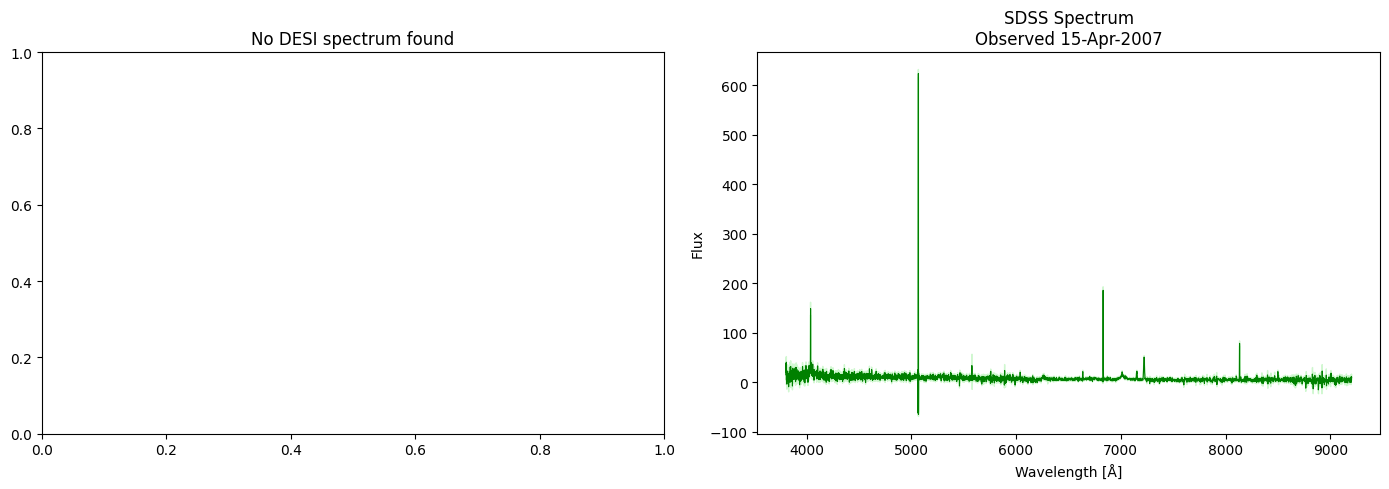

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/dark/262/26277/coadd-dr1-dark-26277.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/bright/262/26277/coadd-dr1-bright-26277.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/dark/262/26277/coadd-sv3-dark-26277.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/bright/262/26277/coadd-sv3-bright-26277.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/dark/262/26277/coadd-sv1-dark-26277.fits
Warning no spectra was found with provided info
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/bright/262/26277/coadd-sv1-bright-26277.fits
Warning no spectra was found with provided info


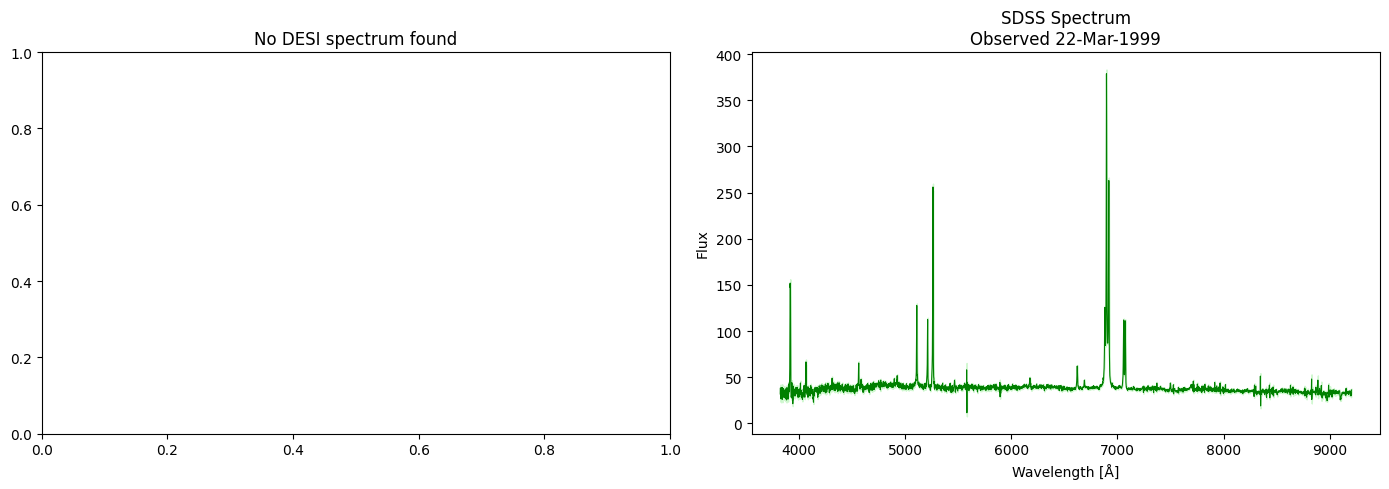

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/dark/114/11406/coadd-dr1-dark-11406.fits


https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/bright/114/11406/coadd-dr1-bright-11406.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/dark/114/11406/coadd-sv3-dark-11406.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/bright/114/11406/coadd-sv3-bright-11406.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/dark/114/11406/coadd-sv1-dark-11406.fits
Warning no spectra was found with provided info
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/bright/114/11406/coadd-sv1-bright-11406.fits


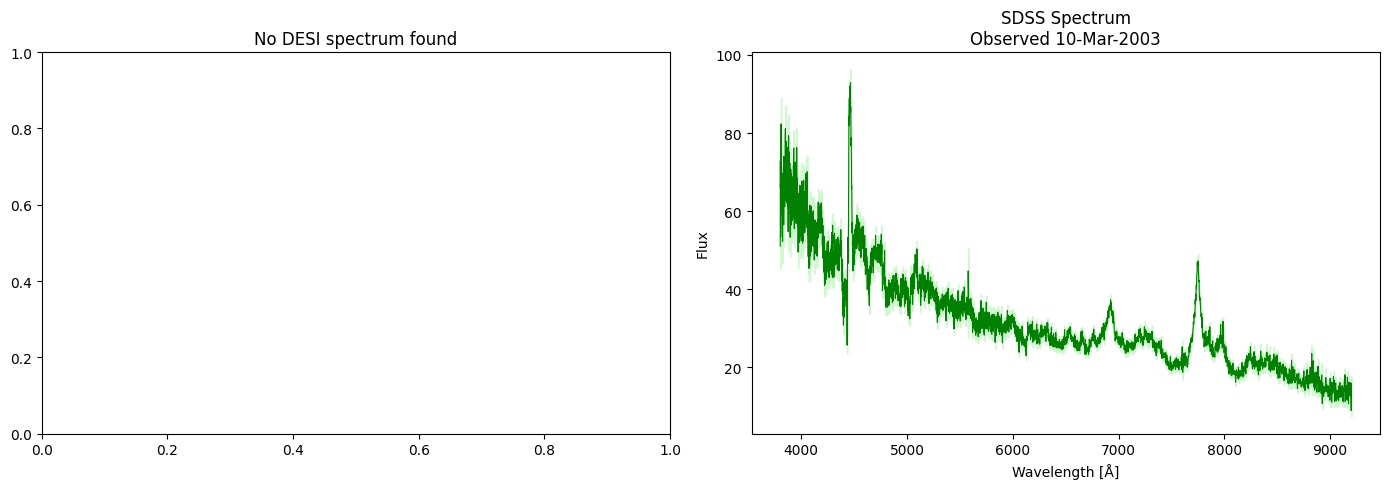

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/dark/98/9845/coadd-dr1-dark-9845.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/dr1/bright/98/9845/coadd-dr1-bright-9845.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/dark/98/9845/coadd-sv3-dark-9845.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv3/bright/98/9845/coadd-sv3-bright-9845.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/dark/98/9845/coadd-sv1-dark-9845.fits
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/sv1/bright/98/9845/coadd-sv1-bright-9845.fits


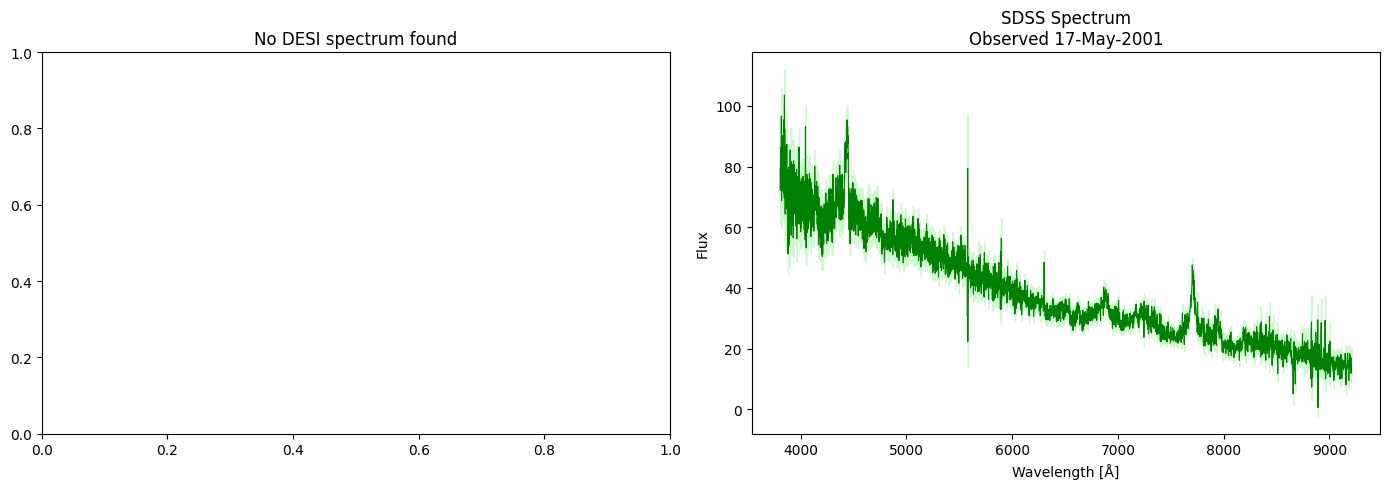

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u

import desi_retriever.dr1 as dr1


# ----------------------------
# Objects: RA, DEC, TARGETID, SDSS date
# ----------------------------
objects = [
    (212.1152,   0.80423,    39627806405036766, "15-Apr-2007"),
    (184.61126, -0.1305556,  39627781784471770, "22-Mar-1999"),
    (217.36365, 52.647076,   39633290071641162, "10-Mar-2003"),
    (245.13714, 44.380412,   39633158374688229, "17-May-2001"),
]


# DESI healpix setup
NSIDE = 64
NEST  = True

SURVEY_PROGRAMS = [
    ("dr1", "dark"),
    ("dr1", "bright"),
    ("sv3", "dark"),
    ("sv3", "bright"),
    ("sv1", "dark"),
    ("sv1", "bright"),
]


def radec_to_hpx(ra, dec):
    theta = np.radians(90 - dec)
    phi   = np.radians(ra)
    return hp.ang2pix(NSIDE, theta, phi, nest=NEST)


def get_desi_spectrum(ra, dec, targetid):
    """Return wave, flux, sigma, survey, program or None"""
    hpx = radec_to_hpx(ra, dec)

    for survey, program in SURVEY_PROGRAMS:
        try:
            spec = dr1.get_specs(
                survey=survey,
                program=program,
                hpx=hpx,
                targetid=targetid
            )[0]

            wave = spec["wave"]
            flux = spec["flux"]
            ivar = spec["ivar"]

            sigma = np.zeros_like(ivar)
            m = ivar > 0
            sigma[m] = 1 / np.sqrt(ivar[m])
            sigma[~m] = np.nan

            return wave, flux, sigma, survey, program

        except Exception:
            continue

    return None, None, None, None, None


# ----------------------------
# Main loop
# ----------------------------
for ra, dec, tid, sdss_date in objects:

    # ---------- SDSS ----------
    pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
    xid = SDSS.query_region(pos, spectro=True, radius=2 * u.arcsec)

    sdss_wave = sdss_flux = sdss_err = None

    if xid is not None:
        spectra = SDSS.get_spectra(matches=xid)
        if spectra:
            spec = spectra[0][1].data
            sdss_wave = 10 ** spec["loglam"]
            sdss_flux = spec["flux"]

            if "ivar" in spec.names:
                ivar = spec["ivar"]
                sdss_err = np.zeros_like(ivar)
                m = ivar > 0
                sdss_err[m] = 1 / np.sqrt(ivar[m])
                sdss_err[~m] = np.nan

    # ---------- DESI ----------
    desi_wave, desi_flux, desi_sigma, survey, program = \
        get_desi_spectrum(ra, dec, tid)

    # ---------- Plot ----------
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # DESI
    if desi_wave is not None:
        axs[0].plot(desi_wave, desi_flux, color="purple", lw=0.8)
        axs[0].fill_between(
            desi_wave,
            desi_flux - desi_sigma,
            desi_flux + desi_sigma,
            color="lavender",
            alpha=0.4
        )
        axs[0].set_title(f"DESI ({survey}/{program})\nTARGETID {tid}")
        axs[0].set_xlabel("Wavelength [Å]")
        axs[0].set_ylabel("Flux")

    else:
        axs[0].set_title("No DESI spectrum found")

    # SDSS
    if sdss_wave is not None:
        axs[1].plot(sdss_wave, sdss_flux, color="green", lw=0.8)
        if sdss_err is not None:
            axs[1].fill_between(
                sdss_wave,
                sdss_flux - sdss_err,
                sdss_flux + sdss_err,
                color="lightgreen",
                alpha=0.4
            )
        axs[1].set_title(f"SDSS Spectrum\nObserved {sdss_date}")
        axs[1].set_xlabel("Wavelength [Å]")
        axs[1].set_ylabel("Flux")

    else:
        axs[1].set_title("No SDSS spectrum found")

    plt.tight_layout()
    plt.show()


In [4]:
import os
print(os.getcwd())

/Users/gracedavis/WORK STUFF/CLQcandidatework


In [3]:
print(os.listdir())

['sdssvsdesi.ipynb', 'cosmos_catalog_v1.fits', 'tryingsomething.ipynb', 'LCandDESI.ipynb', 'sdss_desi_comparison_summary.csv', 'DESIspectra.ipynb', 'spectra-main-bright-26007_tmp7295.fits', 'IsolateAGN.ipynb', '.ipynb_checkpoints', 'justsdss.ipynb', 'apjlacfa03t1_mrt.txt', 'difference spectrum.ipynb']


In [5]:
from py_compile import main

from astropy.io import fits

hdul = fits.open("spectra-main-bright-26007_tmp7295.fits")

In [6]:
import numpy as np

TARGETID = 39627806405036766

fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]

print(idx)

i = idx[0]  # row index for your object

[423]


In [7]:
import numpy as np

wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data,
])

flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i],
])

ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i],
])

sigma = np.zeros_like(ivar)
m = ivar > 0
sigma[m] = 1 / np.sqrt(ivar[m])
sigma[~m] = np.nan


In [ ]:
#not needed anything before this

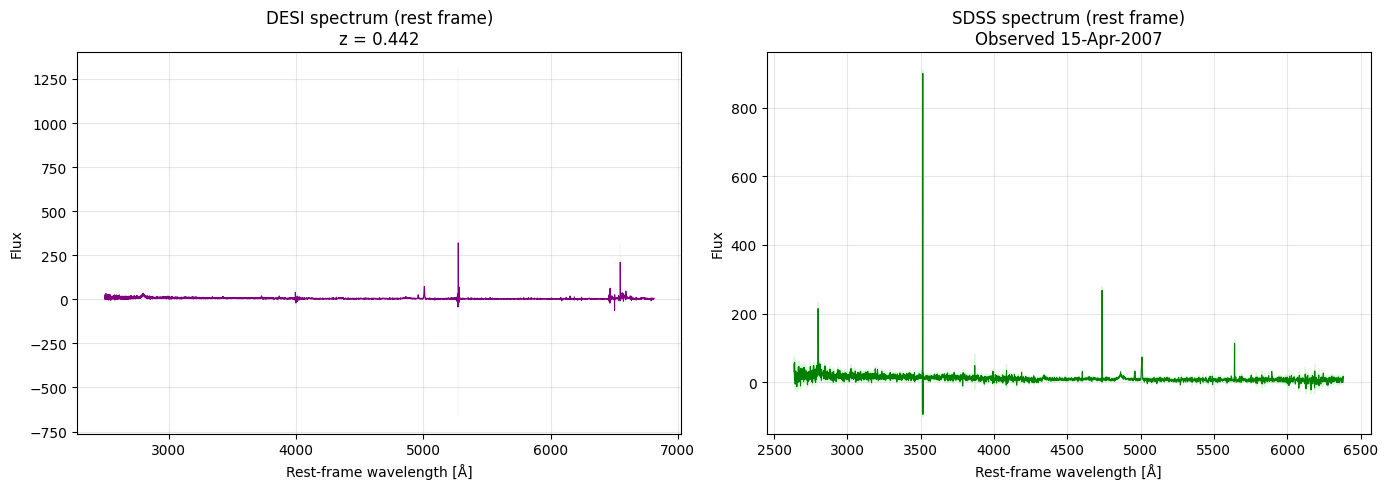

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u


# -----------------------------
# Inputs
# -----------------------------
DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"
TARGETID  = 39627806405036766
RA  = 212.1152
DEC = 0.80423
SDSS_DATE = "15-Apr-2007"
z = 0.442   # redshift


# -----------------------------
# Load DESI spectrum
# -----------------------------
hdul = fits.open(DESI_FILE)

fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]
if len(idx) == 0:
    raise RuntimeError("TARGETID not found in DESI file")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data,
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i],
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i],
])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1.0 / np.sqrt(desi_ivar[m])


# -----------------------------
# Rest-frame correction (DESI)
# -----------------------------
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)


# -----------------------------
# Load SDSS spectrum
# -----------------------------
pos = SkyCoord(RA, DEC, unit="deg", frame="icrs")
xid = SDSS.query_region(pos, spectro=True, radius=2 * u.arcsec)

sdss_wave_rest = sdss_flux_rest = sdss_err_rest = None

if xid is not None:
    specs = SDSS.get_spectra(matches=xid)
    if specs:
        spec = specs[0][1].data

        sdss_wave = 10 ** spec["loglam"]
        sdss_flux = spec["flux"]

        if "ivar" in spec.names:
            ivar = spec["ivar"]
            sdss_err = np.full_like(ivar, np.nan)
            m = ivar > 0
            sdss_err[m] = 1.0 / np.sqrt(ivar[m])
        else:
            sdss_err = None

        # -----------------------------
        # Rest-frame correction (SDSS)
        # -----------------------------
        sdss_wave_rest = sdss_wave / (1 + z)
        sdss_flux_rest = sdss_flux * (1 + z)
        if sdss_err is not None:
            sdss_err_rest = sdss_err * (1 + z)


# -----------------------------
# Plot side-by-side (rest frame)
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# DESI
axs[0].plot(desi_wave_rest, desi_flux_rest, lw=0.8, color="purple")
axs[0].fill_between(
    desi_wave_rest,
    desi_flux_rest - desi_err_rest,
    desi_flux_rest + desi_err_rest,
    alpha=0.3,
    color="lavender"
)
axs[0].set_title("DESI spectrum (rest frame)\nz = 0.442")
axs[0].set_xlabel("Rest-frame wavelength [Å]")
axs[0].set_ylabel("Flux")
axs[0].grid(alpha=0.3)

# SDSS
if sdss_wave_rest is not None:
    axs[1].plot(sdss_wave_rest, sdss_flux_rest, lw=0.8, color="green")
    if sdss_err_rest is not None:
        axs[1].fill_between(
            sdss_wave_rest,
            sdss_flux_rest - sdss_err_rest,
            sdss_flux_rest + sdss_err_rest,
            alpha=0.3,
            color="lightgreen"
        )
    axs[1].set_title(f"SDSS spectrum (rest frame)\nObserved {SDSS_DATE}")
    axs[1].set_xlabel("Rest-frame wavelength [Å]")
    axs[1].set_ylabel("Flux")
    axs[1].grid(alpha=0.3)
else:
    axs[1].set_title("No SDSS spectrum found")

plt.tight_layout()
plt.show()


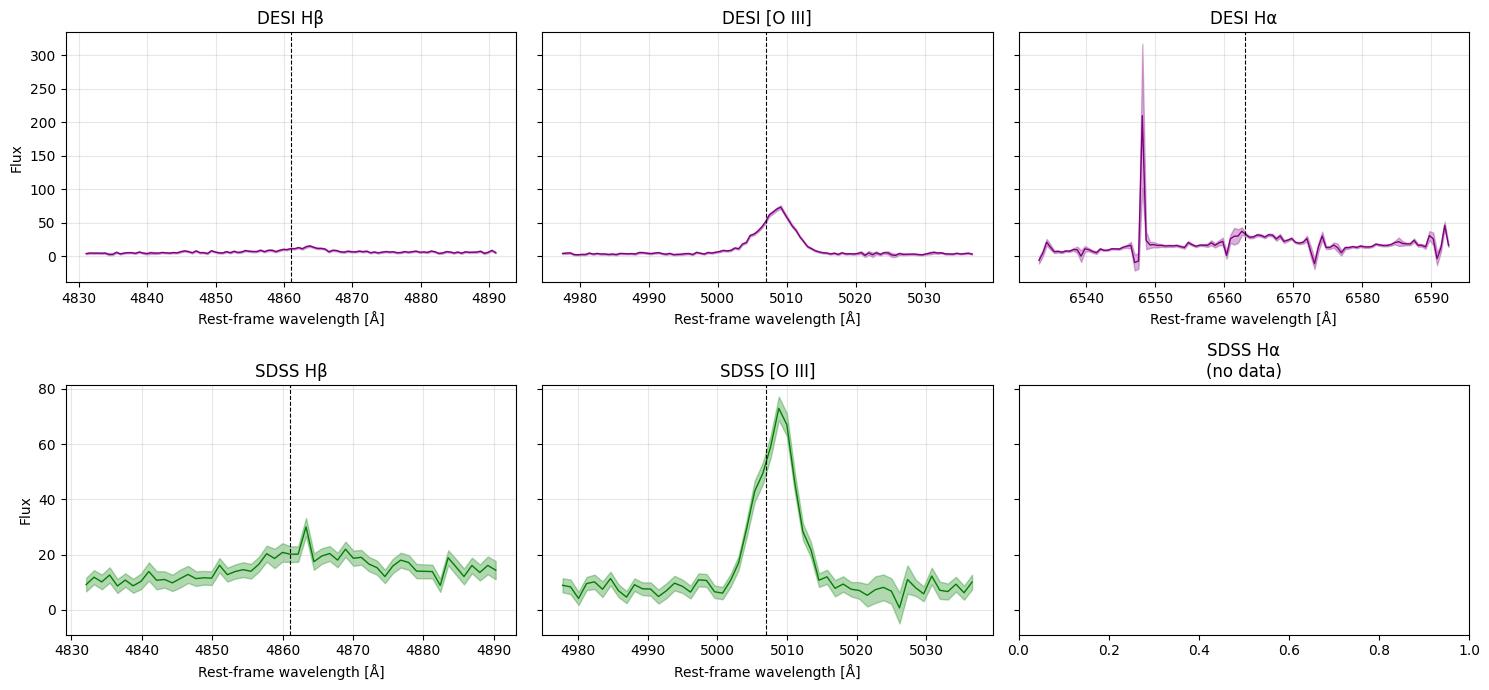

In [9]:
# -----------------------------
# Rest-frame line definitions
# -----------------------------
z = 0.442

LINES = {
    "Hβ": 4861.0,
    "[O III]": 5007.0,
    "Hα": 6563.0
}

WINDOW = 30  # Å on each side


# -----------------------------
# Rest-frame correction
# -----------------------------
desi_wave_rest = desi_wave / (1 + z)
sdss_wave_rest = sdss_wave / (1 + z)

desi_flux_rest = desi_flux * (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)

desi_err_rest = desi_err * (1 + z)
sdss_err_rest = sdss_err * (1 + z)


# -----------------------------
# Zoom plotting function
# -----------------------------
def plot_zoom(ax, wave, flux, err, line_wave, color, title):
    mask = (wave > line_wave - WINDOW) & (wave < line_wave + WINDOW)

    if not np.any(mask):
        ax.set_title(f"{title}\n(no data)")
        return

    ax.plot(wave[mask], flux[mask], color=color, lw=1)

    if err is not None:
        ax.fill_between(
            wave[mask],
            flux[mask] - err[mask],
            flux[mask] + err[mask],
            color=color,
            alpha=0.3
        )

    ax.axvline(line_wave, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Rest-frame wavelength [Å]")
    ax.set_title(title)
    ax.grid(alpha=0.3)


# -----------------------------
# Plot grid
# -----------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 7), sharey="row")

line_items = list(LINES.items())

# ---------- DESI (top row) ----------
for j, (name, lwave) in enumerate(line_items):
    plot_zoom(
        axs[0, j],
        desi_wave_rest,
        desi_flux_rest,
        desi_err_rest,
        lwave,
        color="purple",
        title=f"DESI {name}"
    )

# ---------- SDSS (bottom row) ----------
for j, (name, lwave) in enumerate(line_items):
    plot_zoom(
        axs[1, j],
        sdss_wave_rest,
        sdss_flux_rest,
        sdss_err_rest,
        lwave,
        color="green",
        title=f"SDSS {name}"
    )

axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")

plt.tight_layout()
plt.show()


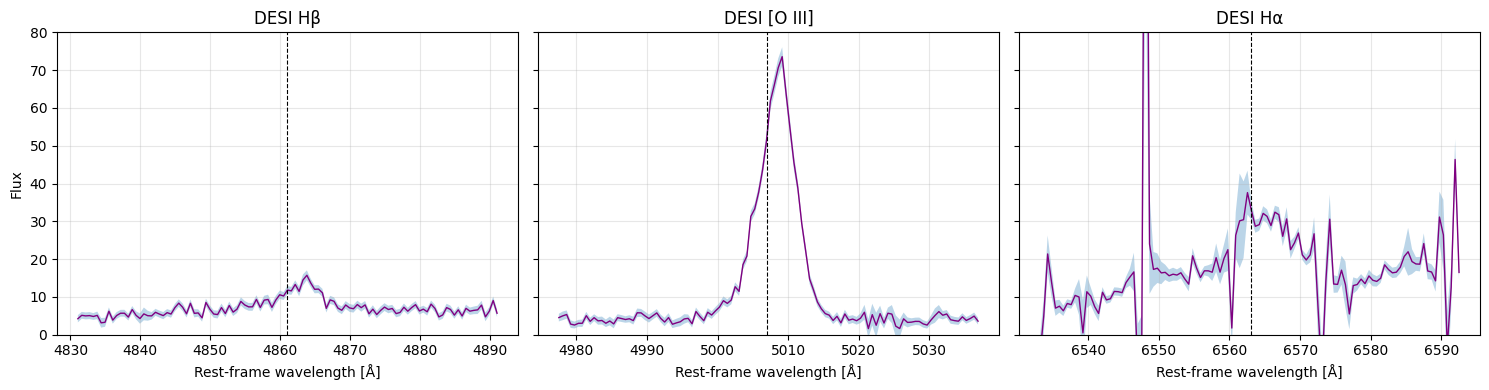

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# -----------------------------
# Inputs
# -----------------------------
DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"
TARGETID  = 39627806405036766
z = 0.442  # redshift

LINES = {
    "Hβ": 4861.0,
    "[O III]": 5007.0,
    "Hα": 6563.0
}

WINDOW = 30  # Å


# -----------------------------
# Load DESI spectrum
# -----------------------------
hdul = fits.open(DESI_FILE)

fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]
if len(idx) == 0:
    raise RuntimeError("TARGETID not found in DESI file")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data,
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i],
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i],
])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1.0 / np.sqrt(desi_ivar[m])


# -----------------------------
# Rest-frame correction
# -----------------------------
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)


# -----------------------------
# Zoom plotting function
# -----------------------------
def plot_zoom(ax, wave, flux, err, line_wave, title):
    mask = (wave > line_wave - WINDOW) & (wave < line_wave + WINDOW)
    w = wave[mask]
    f = flux[mask]
    e = err[mask]

    if len(w) == 0:
        ax.set_title(f"{title}\n(no data)")
        return

    ax.plot(w, f, color="purple", lw=1)
    ax.fill_between(w, f - e, f + e, alpha=0.3)

    # --- FIXED y-axis ---
    ax.set_ylim(0, 80)

    ax.axvline(line_wave, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Rest-frame wavelength [Å]")
    ax.set_title(title)
    ax.grid(alpha=0.3)


# -----------------------------
# Plot DESI zooms
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, lwave) in zip(axs, LINES.items()):
    plot_zoom(
        ax,
        desi_wave_rest,
        desi_flux_rest,
        desi_err_rest,
        lwave,
        title=f"DESI {name}"
    )

axs[0].set_ylabel("Flux")
plt.tight_layout()
plt.show()


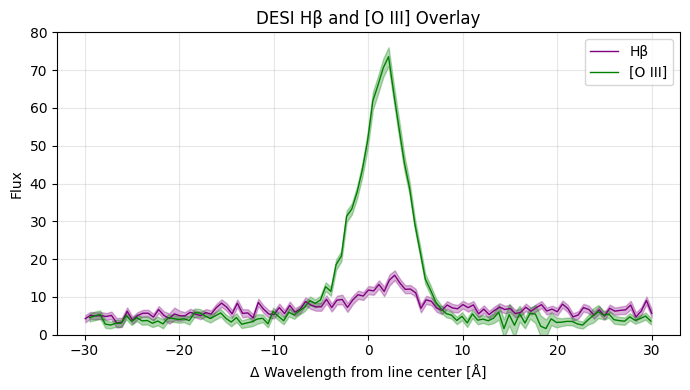

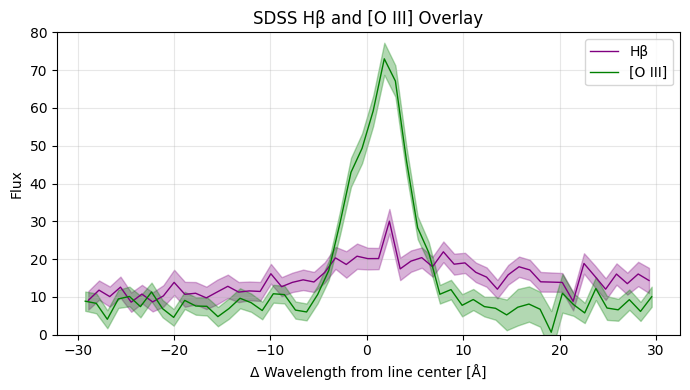

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u

# ==========================================================
# Common Inputs
# ==========================================================
TARGETID  = 39627806405036766
DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"

RA  = 212.1152
DEC = 0.80423
z   = 0.442

LINES = {"Hβ": 4861.0,
         "[O III]": 5007.0}

WINDOW = 30
colors = ["purple", "green"]


# ==========================================================
# -------------------- DESI PLOT ---------------------------
# ==========================================================
hdul = fits.open(DESI_FILE)
fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]

if len(idx) == 0:
    raise RuntimeError("TARGETID not found in DESI file")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data,
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i],
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i],
])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1.0 / np.sqrt(desi_ivar[m])

# Rest frame correction
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)

# Create DESI figure
fig1, ax1 = plt.subplots(figsize=(7,4))

for (name, line_wave), color in zip(LINES.items(), colors):
    delta_wave = desi_wave_rest - line_wave
    mask = (delta_wave > -WINDOW) & (delta_wave < WINDOW)

    w = delta_wave[mask]
    f = desi_flux_rest[mask]
    e = desi_err_rest[mask]

    ax1.plot(w, f, color=color, lw=1, label=name)
    ax1.fill_between(w, f-e, f+e, color=color, alpha=0.3)

ax1.set_ylim(0, 80)
ax1.set_xlabel("Δ Wavelength from line center [Å]")
ax1.set_ylabel("Flux")
ax1.set_title("DESI Hβ and [O III] Overlay")
ax1.legend()
ax1.grid(alpha=0.3)

plt.tight_layout()


# ==========================================================
# -------------------- SDSS PLOT ---------------------------
# ==========================================================
co = coords.SkyCoord(RA, DEC, unit=(u.deg, u.deg))
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)

if len(sp) == 0:
    raise RuntimeError("No SDSS spectrum found")

hdul_sdss = sp[0]

sdss_flux = hdul_sdss[1].data['flux']
sdss_wave = 10 ** hdul_sdss[1].data['loglam']
sdss_ivar = hdul_sdss[1].data['ivar']

sdss_err = np.zeros_like(sdss_ivar)
mask = sdss_ivar > 0
sdss_err[mask] = 1 / np.sqrt(sdss_ivar[mask])

# Rest frame
sdss_wave_rest = sdss_wave / (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)
sdss_err_rest  = sdss_err * (1 + z)

# Create SDSS figure
fig2, ax2 = plt.subplots(figsize=(7,4))

for (name, line_wave), color in zip(LINES.items(), colors):
    delta_wave = sdss_wave_rest - line_wave
    mask = (delta_wave > -WINDOW) & (delta_wave < WINDOW)

    if not np.any(mask):
        continue

    w = delta_wave[mask]
    f = sdss_flux_rest[mask]
    e = sdss_err_rest[mask]

    ax2.plot(w, f, color=color, lw=1, label=name)
    ax2.fill_between(w, f-e, f+e, color=color, alpha=0.3)

ax2.set_ylim(0, 80)
ax2.set_xlabel("Δ Wavelength from line center [Å]")
ax2.set_ylabel("Flux")
ax2.set_title("SDSS Hβ and [O III] Overlay")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



================ SDSS FITS ================

Hβ
  μ = 4861.00 Å
  σ = 3.00 Å
  Flux = 1.205e+02

[O III]
  μ = 5007.00 Å
  σ = 3.00 Å
  Flux = 4.836e+02

SDSS [O III]/Hβ = 4.013

================ DESI FITS ================

Hβ
  μ = 4862.98 Å
  σ = 3.38 Å
  Flux = 5.827e+01

[O III]
  μ = 5008.44 Å
  σ = 2.62 Å
  Flux = 4.091e+02

DESI [O III]/Hβ = 7.020


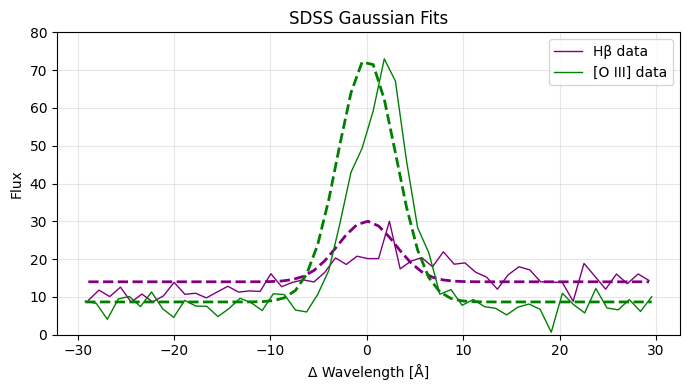

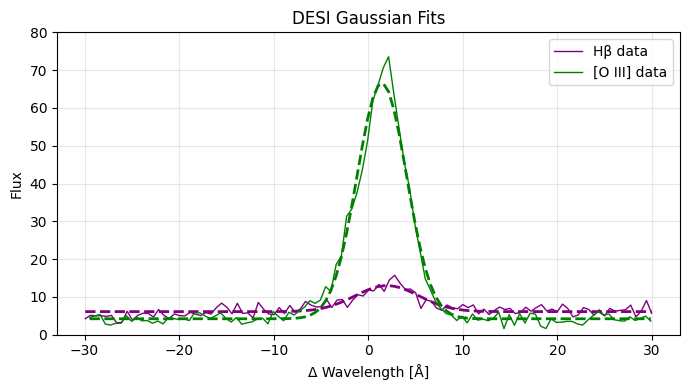

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from scipy.optimize import minimize

# ============================================================
# Common Inputs
# ============================================================
RA  = 212.1152
DEC = 0.80423
TARGETID  = 39627806405036766
DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"
z   = 0.442

LINES = {
    "Hβ": 4861.0,
    "[O III]": 5007.0
}

WINDOW = 30
colors = {"Hβ": "purple", "[O III]": "green"}


# ============================================================
# Gaussian model + chi-square
# ============================================================
def gaussian_model(w, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((w - mu) / sigma)**2) + C

def chi2(params, w, f, e):
    A, mu, sigma, C = params
    model = gaussian_model(w, A, mu, sigma, C)
    return np.sum(((f - model) / e)**2)

def fit_emission_line(w, f, e, mu_guess):

    A0 = np.nanmax(f) - np.nanmedian(f)
    sigma0 = 3.0
    C0 = np.nanmedian(f)

    p0 = [A0, mu_guess, sigma0, C0]

    bounds = [
        (0, None),
        (mu_guess - 5, mu_guess + 5),
        (0.5, 20),
        (0, None)
    ]

    result = minimize(chi2, p0, args=(w, f, e), bounds=bounds)

    if not result.success:
        raise RuntimeError("Gaussian fit failed")

    A, mu, sigma, C = result.x

    flux = A * sigma * np.sqrt(2*np.pi)

    return {
        "A": A,
        "mu": mu,
        "sigma": sigma,
        "baseline": C,
        "flux": flux
    }


# ============================================================
# ===================== SDSS SECTION ========================
# ============================================================
print("\n================ SDSS FITS ================")

co = coords.SkyCoord(RA, DEC, unit=(u.deg, u.deg))
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)

if len(sp) == 0:
    raise RuntimeError("No SDSS spectrum found")

hdul_sdss = sp[0]

sdss_flux = hdul_sdss[1].data["flux"]
sdss_wave = 10**hdul_sdss[1].data["loglam"]
sdss_ivar = hdul_sdss[1].data["ivar"]

sdss_err = np.zeros_like(sdss_ivar)
good = sdss_ivar > 0
sdss_err[good] = 1 / np.sqrt(sdss_ivar[good])

# Rest-frame
sdss_wave_rest = sdss_wave / (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)
sdss_err_rest  = sdss_err  * (1 + z)

sdss_results = {}

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    if not np.any(mask):
        continue

    w = sdss_wave_rest[mask]
    f = sdss_flux_rest[mask]
    e = sdss_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    sdss_results[name] = fit_emission_line(w, f, e, line_wave)

# Print SDSS results
for name, res in sdss_results.items():
    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} Å")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nSDSS [O III]/Hβ = {sdss_results['[O III]']['flux']/sdss_results['Hβ']['flux']:.3f}")


# ---- SDSS Plot ----
fig1, ax1 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = sdss_flux_rest[mask]

    ax1.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = sdss_results[name]
    model = gaussian_model(
        sdss_wave_rest[mask],
        res["A"], res["mu"], res["sigma"], res["baseline"]
    )

    ax1.plot(w, model, ls="--", color=colors[name], lw=2)

ax1.set_ylim(0,80)
ax1.set_xlabel("Δ Wavelength [Å]")
ax1.set_ylabel("Flux")
ax1.set_title("SDSS Gaussian Fits")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()


# ============================================================
# ===================== DESI SECTION ========================
# ============================================================
print("\n================ DESI FITS ================")

hdul = fits.open(DESI_FILE)
fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]

if len(idx) == 0:
    raise RuntimeError("TARGETID not found")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i]
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i]
])

desi_err = np.zeros_like(desi_ivar)
good = desi_ivar > 0
desi_err[good] = 1 / np.sqrt(desi_ivar[good])

# Rest-frame
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)

desi_results = {}

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = desi_wave_rest[mask]
    f = desi_flux_rest[mask]
    e = desi_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    desi_results[name] = fit_emission_line(w, f, e, line_wave)

# Print DESI results
for name, res in desi_results.items():
    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} Å")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nDESI [O III]/Hβ = {desi_results['[O III]']['flux']/desi_results['Hβ']['flux']:.3f}")


# ---- DESI Plot ----
fig2, ax2 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = desi_flux_rest[mask]

    ax2.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = desi_results[name]
    model = gaussian_model(
        desi_wave_rest[mask],
        res["A"], res["mu"], res["sigma"], res["baseline"]
    )

    ax2.plot(w, model, ls="--", color=colors[name], lw=2)

ax2.set_ylim(0,80)
ax2.set_xlabel("Δ Wavelength [Å]")
ax2.set_ylabel("Flux")
ax2.set_title("DESI Gaussian Fits")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



================ SDSS FITS ================

Hβ
  μ = 4865.16 ± 0.94 Å
  σ = 8.09 ± 1.25 Å
  σ_v = 498.96 km/s
  Flux = 1.875e+02

[O III]
  μ = 5008.51 ± 0.11 Å
  σ = 2.76 ± 0.10 Å
  σ_v = 165.22 km/s
  Flux = 4.208e+02

SDSS [O III]/Hβ = 2.244

================ DESI FITS ================

Hβ
  μ = 4862.98 ± 0.23 Å
  σ = 3.38 ± 0.25 Å
  σ_v = 208.53 km/s
  Flux = 5.828e+01

[O III]
  μ = 5008.44 ± 0.03 Å
  σ = 2.62 ± 0.03 Å
  σ_v = 156.73 km/s
  Flux = 4.091e+02

DESI [O III]/Hβ = 7.020


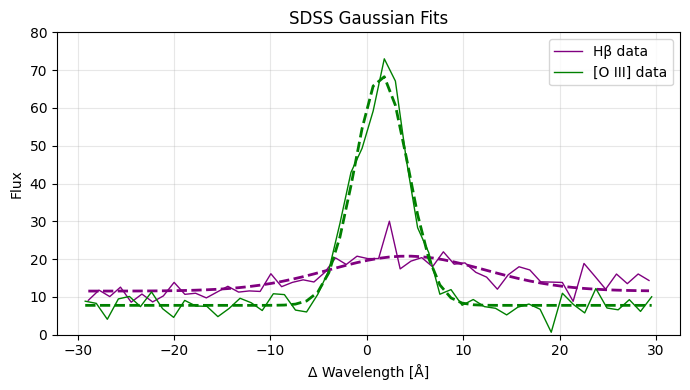

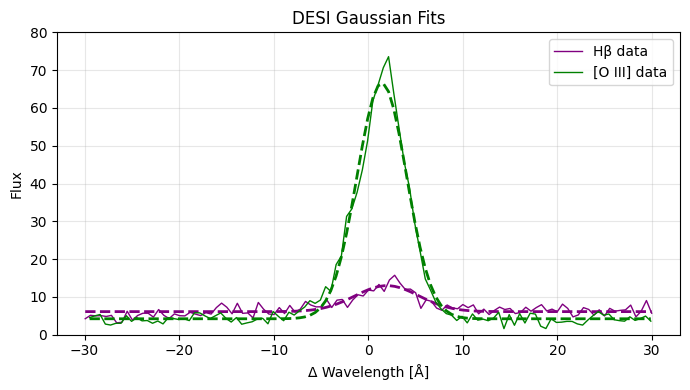

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from scipy.optimize import curve_fit

# ============================================================
# Inputs
# ============================================================
RA  = 212.1152
DEC = 0.80423
TARGETID  = 39627806405036766
DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"
z   = 0.442

LINES = {
    "Hβ": 4861.0,
    "[O III]": 5007.0
}

WINDOW = 30
colors = {"Hβ": "purple", "[O III]": "green"}

# Speed of light for velocity conversion
c = 299792.458  # km/s


# ============================================================
# Gaussian Fit Function (WITH uncertainties)
# ============================================================
def fit_emission_line(w, f, e, mu_guess):

    def gaussian_model(w, A, mu, sigma, C):
        return A * np.exp(-0.5 * ((w - mu) / sigma)**2) + C

    A0 = np.nanmax(f) - np.nanmedian(f)
    sigma0 = 3.0
    C0 = np.nanmedian(f)

    p0 = [A0, mu_guess, sigma0, C0]

    bounds = (
        [0, mu_guess-5, 0.5, 0],
        [np.inf, mu_guess+5, 20, np.inf]
    )

    popt, pcov = curve_fit(
        gaussian_model,
        w,
        f,
        p0=p0,
        sigma=e,
        absolute_sigma=True,
        bounds=bounds
    )

    A, mu, sigma, C = popt
    perr = np.sqrt(np.diag(pcov))
    A_err, mu_err, sigma_err, C_err = perr

    flux = A * sigma * np.sqrt(2*np.pi)

    return {
        "A": A,
        "mu": mu,
        "sigma": sigma,
        "baseline": C,
        "flux": flux,
        "mu_err": mu_err,
        "sigma_err": sigma_err
    }


# ============================================================
# ====================== SDSS SECTION ========================
# ============================================================
print("\n================ SDSS FITS ================")

co = coords.SkyCoord(RA, DEC, unit=(u.deg, u.deg))
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)

if len(sp) == 0:
    raise RuntimeError("No SDSS spectrum found")

hdul_sdss = sp[0]

sdss_flux = hdul_sdss[1].data["flux"]
sdss_wave = 10**hdul_sdss[1].data["loglam"]
sdss_ivar = hdul_sdss[1].data["ivar"]

sdss_err = np.zeros_like(sdss_ivar)
good = sdss_ivar > 0
sdss_err[good] = 1 / np.sqrt(sdss_ivar[good])

# Rest-frame correction
sdss_wave_rest = sdss_wave / (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)
sdss_err_rest  = sdss_err  * (1 + z)

sdss_results = {}

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = sdss_wave_rest[mask]
    f = sdss_flux_rest[mask]
    e = sdss_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    sdss_results[name] = fit_emission_line(w, f, e, line_wave)

# Print SDSS results
for name, res in sdss_results.items():

    sigma_v = (res["sigma"] / LINES[name]) * c

    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} ± {res['mu_err']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} ± {res['sigma_err']:.2f} Å")
    print(f"  σ_v = {sigma_v:.2f} km/s")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nSDSS [O III]/Hβ = "
      f"{sdss_results['[O III]']['flux']/sdss_results['Hβ']['flux']:.3f}")


# SDSS Plot
fig1, ax1 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = sdss_flux_rest[mask]

    ax1.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = sdss_results[name]
    model = (
        res["A"] *
        np.exp(-0.5 * ((sdss_wave_rest[mask] - res["mu"]) / res["sigma"])**2)
        + res["baseline"]
    )

    ax1.plot(w, model, ls="--", color=colors[name], lw=2)

ax1.set_ylim(0,80)
ax1.set_xlabel("Δ Wavelength [Å]")
ax1.set_ylabel("Flux")
ax1.set_title("SDSS Gaussian Fits")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()


# ============================================================
# ====================== DESI SECTION ========================
# ============================================================
print("\n================ DESI FITS ================")

hdul = fits.open(DESI_FILE)
fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]

if len(idx) == 0:
    raise RuntimeError("TARGETID not found")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i]
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i]
])

desi_err = np.zeros_like(desi_ivar)
good = desi_ivar > 0
desi_err[good] = 1 / np.sqrt(desi_ivar[good])

# Rest-frame
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)

desi_results = {}

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = desi_wave_rest[mask]
    f = desi_flux_rest[mask]
    e = desi_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    desi_results[name] = fit_emission_line(w, f, e, line_wave)

# Print DESI results
for name, res in desi_results.items():

    sigma_v = (res["sigma"] / LINES[name]) * c

    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} ± {res['mu_err']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} ± {res['sigma_err']:.2f} Å")
    print(f"  σ_v = {sigma_v:.2f} km/s")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nDESI [O III]/Hβ = "
      f"{desi_results['[O III]']['flux']/desi_results['Hβ']['flux']:.3f}")


# DESI Plot
fig2, ax2 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = desi_flux_rest[mask]

    ax2.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = desi_results[name]
    model = (
        res["A"] *
        np.exp(-0.5 * ((desi_wave_rest[mask] - res["mu"]) / res["sigma"])**2)
        + res["baseline"]
    )

    ax2.plot(w, model, ls="--", color=colors[name], lw=2)

ax2.set_ylim(0,80)
ax2.set_xlabel("Δ Wavelength [Å]")
ax2.set_ylabel("Flux")
ax2.set_title("DESI Gaussian Fits")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


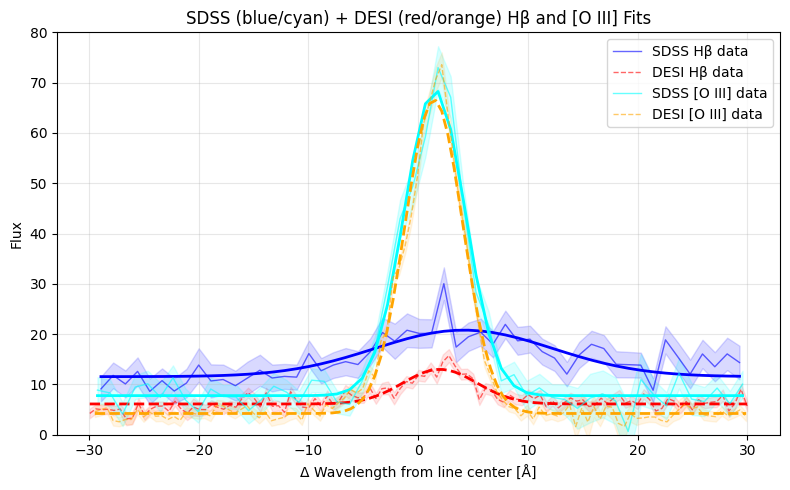

In [10]:
# ============================================================
# ONE Combined Plot with Different Colors for SDSS/DESI
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))

# Define colors
survey_colors = {
    "SDSS": {"Hβ": "blue", "[O III]": "cyan"},
    "DESI": {"Hβ": "red", "[O III]": "orange"}
}

for name, line_wave in LINES.items():

    # ---------- SDSS ----------
    delta_sdss = sdss_wave_rest - line_wave
    mask_sdss = (delta_sdss > -WINDOW) & (delta_sdss < WINDOW)
    w_sdss = delta_sdss[mask_sdss]
    f_sdss = sdss_flux_rest[mask_sdss]
    e_sdss = sdss_err_rest[mask_sdss]

    # Plot SDSS data
    ax.plot(w_sdss, f_sdss, color=survey_colors["SDSS"][name], lw=1, alpha=0.6, label=f"SDSS {name} data")
    ax.fill_between(w_sdss, f_sdss-e_sdss, f_sdss+e_sdss, color=survey_colors["SDSS"][name], alpha=0.15)

    # Plot SDSS fit
    res_sdss = sdss_results[name]
    model_sdss = (
        res_sdss["A"] *
        np.exp(-0.5 * ((sdss_wave_rest[mask_sdss] - res_sdss["mu"])
                       / res_sdss["sigma"])**2)
        + res_sdss["baseline"]
    )
    ax.plot(w_sdss, model_sdss, color=survey_colors["SDSS"][name], lw=2)

    # ---------- DESI ----------
    delta_desi = desi_wave_rest - line_wave
    mask_desi = (delta_desi > -WINDOW) & (delta_desi < WINDOW)
    w_desi = delta_desi[mask_desi]
    f_desi = desi_flux_rest[mask_desi]
    e_desi = desi_err_rest[mask_desi]

    # Plot DESI data
    ax.plot(w_desi, f_desi, color=survey_colors["DESI"][name], lw=1, alpha=0.6, linestyle="--", label=f"DESI {name} data")
    ax.fill_between(w_desi, f_desi-e_desi, f_desi+e_desi, color=survey_colors["DESI"][name], alpha=0.1)

    # Plot DESI fit
    res_desi = desi_results[name]
    model_desi = (
        res_desi["A"] *
        np.exp(-0.5 * ((desi_wave_rest[mask_desi] - res_desi["mu"])
                       / res_desi["sigma"])**2)
        + res_desi["baseline"]
    )
    ax.plot(w_desi, model_desi, color=survey_colors["DESI"][name], lw=2, linestyle="--")

# Styling
ax.set_ylim(0, 80)
ax.set_xlabel("Δ Wavelength from line center [Å]")
ax.set_ylabel("Flux")
ax.set_title("SDSS (blue/cyan) + DESI (red/orange) Hβ and [O III] Fits")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



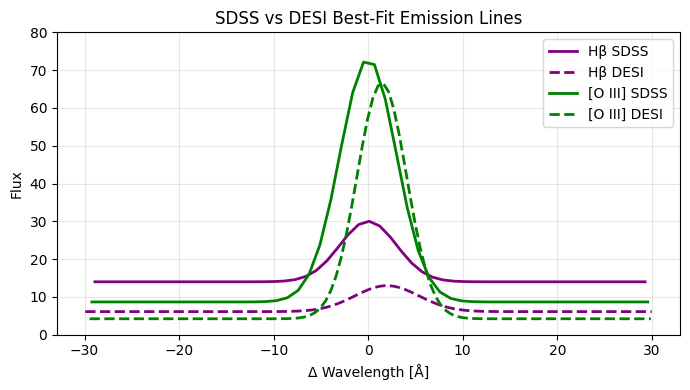

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from astropy.io import fits

# ============================================================
# Inputs
# ============================================================
RA, DEC = 212.1152, 0.80423
z = 0.442

DESI_FILE = "spectra-main-bright-26007_tmp7295.fits"
TARGETID  = 39627806405036766

LINES = {"Hβ": 4861.0, "[O III]": 5007.0}
WINDOW = 30

# ============================================================
# Gaussian + chi²
# ============================================================
def gaussian_model(w, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((w - mu) / sigma)**2) + C

def chi2(p, w, f, e):
    return np.sum(((f - gaussian_model(w, *p)) / e)**2)

def fit_line(w, f, e, mu0):
    p0 = [np.nanmax(f) - np.nanmedian(f), mu0, 3.0, np.nanmedian(f)]
    bounds = [(0,None),(mu0-5,mu0+5),(0.5,20),(0,None)]
    res = minimize(chi2, p0, args=(w,f,e), bounds=bounds)
    if not res.success:
        raise RuntimeError("Fit failed")
    A, mu, sigma, C = res.x
    return {"A":A, "mu":mu, "sigma":sigma, "baseline":C}

# ============================================================
# -------- SDSS --------
# ============================================================
co = coords.SkyCoord(RA, DEC, unit="deg")
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)[0]

sdss_flux = sp[1].data["flux"].copy()
sdss_wave = (10**sp[1].data["loglam"]).copy()
sdss_ivar = sp[1].data["ivar"].copy()

sdss_err = np.full_like(sdss_ivar, np.nan)
m = sdss_ivar > 0
sdss_err[m] = 1 / np.sqrt(sdss_ivar[m])

sdss_wave /= (1+z)
sdss_flux *= (1+z)
sdss_err  *= (1+z)

sdss_fits = {}
for name, lw in LINES.items():
    d = sdss_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)&np.isfinite(sdss_err)
    sdss_fits[name] = fit_line(sdss_wave[m], sdss_flux[m], sdss_err[m], lw)

# ============================================================
# -------- DESI --------
# ============================================================
hdul = fits.open(DESI_FILE)
i = np.where(hdul["FIBERMAP"].data["TARGETID"]==TARGETID)[0][0]

desi_wave = np.concatenate([hdul[f"{b}_WAVELENGTH"].data.copy() for b in "BRZ"])
desi_flux = np.concatenate([hdul[f"{b}_FLUX"].data[i].copy() for b in "BRZ"])
desi_ivar = np.concatenate([hdul[f"{b}_IVAR"].data[i].copy() for b in "BRZ"])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1 / np.sqrt(desi_ivar[m])

desi_wave /= (1+z)
desi_flux *= (1+z)
desi_err  *= (1+z)

desi_fits = {}
for name, lw in LINES.items():
    d = desi_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)&np.isfinite(desi_err)
    desi_fits[name] = fit_line(desi_wave[m], desi_flux[m], desi_err[m], lw)

# ============================================================
# -------- COMBINED PLOT --------
# ============================================================
fig, ax = plt.subplots(figsize=(7,4))
colors = {"Hβ":"purple","[O III]":"green"}

for name, lw in LINES.items():

    # SDSS
    d = sdss_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)
    r = sdss_fits[name]
    ax.plot(
        d[m],
        gaussian_model(sdss_wave[m], r["A"], r["mu"], r["sigma"], r["baseline"]),
        color=colors[name], lw=2, label=f"{name} SDSS"
    )

    # DESI
    d = desi_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)
    r = desi_fits[name]
    ax.plot(
        d[m],
        gaussian_model(desi_wave[m], r["A"], r["mu"], r["sigma"], r["baseline"]),
        color=colors[name], lw=2, ls="--", label=f"{name} DESI"
    )

ax.set_xlabel("Δ Wavelength [Å]")
ax.set_ylabel("Flux")
ax.set_ylim(0,80)
ax.set_title("SDSS vs DESI Best-Fit Emission Lines")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


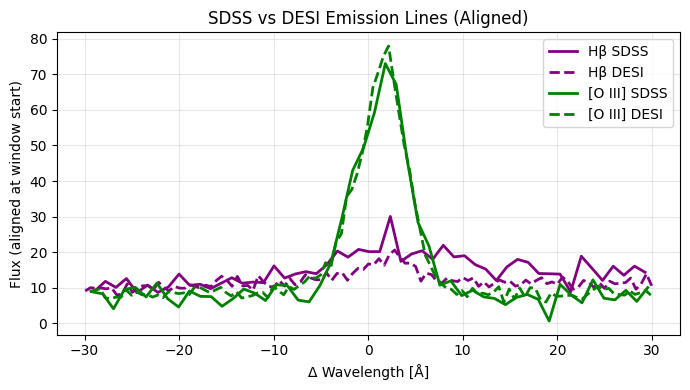

In [12]:
# ============================================================
# -------- ALIGN SDSS AND DESI --------
# ============================================================

fig, ax = plt.subplots(figsize=(7,4))

for name, lw in LINES.items():
    # SDSS and DESI relative wavelength
    sd_d = sdss_wave - lw
    des_d = desi_wave - lw

    # Mask for the window
    sd_mask = (sd_d>-WINDOW) & (sd_d<WINDOW)
    des_mask = (des_d>-WINDOW) & (des_d<WINDOW)

    # Take the flux at the left edge of the SDSS window
    sd_start_flux = sdss_flux[sd_mask][0]
    des_start_flux = desi_flux[des_mask][0]

    # Compute vertical shift to align DESI to SDSS
    shift = sd_start_flux - des_start_flux
    des_flux_shifted = desi_flux[des_mask] + shift

    # Plot SDSS
    ax.plot(sd_d[sd_mask], sdss_flux[sd_mask], color=colors[name], lw=2, label=f"{name} SDSS")
    # Plot shifted DESI
    ax.plot(des_d[des_mask], des_flux_shifted, color=colors[name], lw=2, ls="--", label=f"{name} DESI")

ax.set_xlabel("Δ Wavelength [Å]")
ax.set_ylabel("Flux (aligned at window start)")
ax.set_title("SDSS vs DESI Emission Lines (Aligned)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


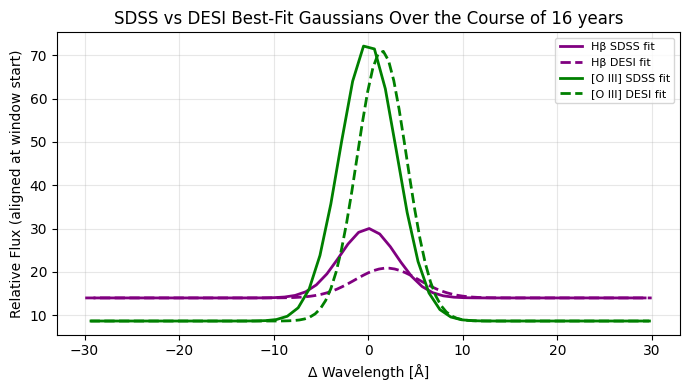

In [14]:
# ============================================================
# -------- BEST-FIT GAUSSIANS ALIGNED AT WINDOW START --------
# ============================================================

fig, ax = plt.subplots(figsize=(7,4))

for name, lw in LINES.items():

    # SDSS and DESI relative wavelength
    sd_d = sdss_wave - lw
    des_d = desi_wave - lw

    # Masks for the window
    sd_mask = (sd_d > -WINDOW) & (sd_d < WINDOW)
    des_mask = (des_d > -WINDOW) & (des_d < WINDOW)

    # Best-fit Gaussians
    sd_r = sdss_fits[name]
    des_r = desi_fits[name]

    sd_gauss = gaussian_model(sdss_wave[sd_mask], sd_r["A"], sd_r["mu"], sd_r["sigma"], sd_r["baseline"])
    des_gauss = gaussian_model(desi_wave[des_mask], des_r["A"], des_r["mu"], des_r["sigma"], des_r["baseline"])

    # Align DESI Gaussian to SDSS at the left edge of the window
    shift = sd_gauss[0] - des_gauss[0]
    des_gauss_shifted = des_gauss + shift

    # Plot best-fit Gaussians only
    ax.plot(sd_d[sd_mask], sd_gauss, color=colors[name], lw=2, label=f"{name} SDSS fit")
    ax.plot(des_d[des_mask], des_gauss_shifted, color=colors[name], lw=2, ls="--", label=f"{name} DESI fit")

ax.set_xlabel("Δ Wavelength [Å]")
ax.set_ylabel("Relative Flux (aligned at window start)")
ax.set_title("SDSS vs DESI Best-Fit Gaussians Over the Course of 16 years")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
